In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from scipy.special import legendre, factorial
import collections.abc
from essentials_bie import *
from density_bie import *

In [7]:
NN = 16
epsilon = np.array([1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])

error0 = np.zeros((len(epsilon)))
error1 = np.zeros((len(epsilon)))
error2 = np.zeros((len(epsilon)))
error3 = np.zeros((len(epsilon)))

KKw = 5

N = NN
M = 2*N
kw = KKw

# compute the Gauss-Legendre quadrature rule in s
μ, ϕ, mu, phi, WTS, ws = GaussLegendre( N )
#print("ws", ws)
s = 0.5 * np.pi * (μ + 1)
# compute the periodic trapezoid rule in t
dt = 2 * np.pi / M
t = np.arange(-np.pi, np.pi, dt)
        
# compute mesh grid
S, T = np.meshgrid(s, t)
Svec = S.flatten()
Tvec = T.flatten()

S2, T2 = np.meshgrid(np.arccos(μ), t)
Svec2 = S2.flatten()
Tvec2 = T2.flatten()
        
n_order = N
mu_nm, mu_nm2 = Computemu(n_order, kw)
print("mu_nm", mu_nm)               
# loop over all ystar values
yll = [1]
for j in yll:
    #j = int((N * M / 16) if lll == 0 else (N * M / 4))
    #STANDAR PGQ
    theta02 = Svec2[j]
    phi02 = Tvec2[j]   
    _, _, ystar2, nustar2, _ = ComputeSurface(0, 0, theta02, phi02)
    theta2, phi2, y2, nu2, J2 = ComputeSurface(theta02, phi02, Svec2, Tvec2) 
    Ynm2, _, _ = ComputeSphericalHarmonics(n_order, theta2, phi2)
    Ynmstar2,_, _ = ComputeSphericalHarmonics(n_order, theta02, phi02)    
    μ2 = Ynm2 @ mu_nm
    print('Ynm2', Ynm2)
    mustar2 = Ynmstar2 @ mu_nm
    print('mu2', μ2, 'mustar2 ', mustar2)
    #NEW METHOD
    theta0 = Svec[j]
    phi0 = Tvec[j]
        
    _, _, ystar, nustar, _ = ComputeSurface(0, 0, theta0, phi0)
    theta, phi, y, nu, J = ComputeSurface(theta0, phi0, Svec, Tvec)
        
    Ynm, _, _ = ComputeSphericalHarmonics(n_order, theta, phi)
    Ynmstar,_, _ = ComputeSphericalHarmonics(n_order, theta0, phi0)
        
    μ = Ynm @ mu_nm
    mustar = Ynmstar @ mu_nm
    #print('μ', μ, 'mustar', mustar)   
    #mu2 = Ynm @ mu_nm2
    #mustar2 = Ynmstar @ mu_nm2
    
    # loop over all epsilon values
    for i in range(len(epsilon)):
        #PGQ
        x12 = ystar2[0] + epsilon[i] * nustar2[0,0]
        x22 = ystar2[1] + epsilon[i] * nustar2[0,1]
        x32 = ystar2[2] + epsilon[i] * nustar2[0,2]
        
        exact2, _, _, _ = ComputeFunction(x12, x22, x32, kw)
        print('exact2', exact2)
        Y12 = x12 - y2[:, 0]
        Y22 = x22 - y2[:, 1]
        Y32 = x32 - y2[:, 2]
        Ylength2 = np.sqrt(Y12**2 + Y22**2 + Y32**2)
        nu_nustar2 = np.sum(nustar2 * nu2, axis=1)
        nu_x_y2 = np.sum(nu2 * np.vstack((Y12, Y22, Y32)).T, axis=1)
        nustar_x_y2 = np.sum(nustar2 * np.vstack((Y12, Y22, Y32)).T, axis=1)
        
        SLP2 = 0.5 * J2 * np.exp(1j * kw * Ylength2) / Ylength2 * np.sin(Svec2)
        DLP2 = ((1 / Ylength2 - 1j * kw) * nu_x_y2 / Ylength2) * SLP2
        K2 = DLP2 - 1j * kw * SLP2
        Kpw2 = DLP2 - 1j * kw * nu_nustar2 * SLP2
        PW2 = mustar * np.exp(-1j * kw * nustar_x_y2)
        #print('mustar', mustar, 'exp', np.exp(-1j * kw * nustar_x_y2))
        #print('Kpw2', Kpw2, 'diff', μ2 - PW2)
        Fbar12 = np.sum(((Kpw2 * (μ2 - PW2))).reshape(M, N), axis=0) / M
        Fbar112 = np.sum((SLP2 * (1j * kw * (1 - nu_nustar2)) * μ2).reshape(M, N), axis=0) / M

        approx0 = np.sum((Fbar12 - Fbar112) * ws)

        #NEW METHOD
        # compute the evaluation point
        x1 = ystar[0] + epsilon[i] * nustar[0,0]
        x2 = ystar[1] + epsilon[i] * nustar[0,1]
        x3 = ystar[2] + epsilon[i] * nustar[0,2]
        
        exact, _, _, _ = ComputeFunction(x1, x2, x3, kw)
        
        Y1 = x1 - y[:, 0]
        Y2 = x2 - y[:, 1]
        Y3 = x3 - y[:, 2]
        Ylength = np.sqrt(Y1**2 + Y2**2 + Y3**2)
        nu_nustar = np.sum(nustar * nu, axis=1)
        nu_x_y = np.sum(nu * np.vstack((Y1, Y2, Y3)).T, axis=1)
        nustar_x_y = np.sum(nustar * np.vstack((Y1, Y2, Y3)).T, axis=1)
        
        SLP = 0.5 * J * np.exp(1j * kw * Ylength) / Ylength * np.sin(Svec)
        DLP = ((1 / Ylength - 1j * kw) * nu_x_y / Ylength) * SLP
        K = DLP - 1j * kw * SLP
        Kpw = DLP - 1j * kw * nu_nustar * SLP
        PW = mustar * np.exp(-1j * kw * nustar_x_y)
        Fbar1 = np.sum(((Kpw * (μ - PW))).reshape(M, N), axis=0) / M
        Fbar11 = np.sum((SLP * (1j * kw * (1 - nu_nustar)) * μ).reshape(M, N), axis=0) / M
        approx1 = np.sum((Fbar1 - Fbar11) * ws)

                
        error0[i] = np.abs(exact - approx0)
        error1[i] = np.abs(exact - approx1)
        #error2[i] = np.abs(exact - approx2)
        #error3[i] = np.abs(exact - approx3)
                
        #errorN0[j, ss, i] = error0
        #errorN1[j, ss, i] = error1
        #errorN2[j, ss, i] = error2
        #errorN3[j, ss, i] = error3
                
        print('   j =', j, 'out of', N * M)
 

mu_nm [ 5.90048067e-01-1.19006191e+00j  8.75539826e-02-9.67565568e-01j
 -1.56772120e+00-9.69590645e-01j  8.26584844e-01-5.10496155e-01j
 -2.22884186e-03-2.21656238e-01j -5.34649582e-01-2.60638265e-01j
 -3.73602691e-01+2.86116506e-01j -1.12279138e-01-5.84102625e-01j
  2.13414065e-01+5.99240584e-02j  1.45628021e-02-3.53836654e-02j
 -8.26034500e-02-9.48088766e-02j -1.77906733e-01+4.60077400e-02j
 -5.75876142e-03+2.69409579e-02j -1.43550232e-01-1.14720742e-01j
  1.14145488e-01-5.27528265e-02j -1.17573256e-03+3.82452172e-02j
  5.59644130e-03-3.12153508e-03j -1.09736563e-03-2.42923724e-02j
 -4.33751347e-02-1.92924203e-02j -2.98051470e-02+2.45313792e-02j
 -4.88028181e-03-2.13232698e-02j -3.75081930e-02-9.12529241e-03j
  3.06657621e-02-3.62382517e-02j  9.57804923e-03+2.23513880e-02j
 -6.39705659e-03-3.76568503e-04j  1.04628723e-03+3.46503878e-04j
  3.30008019e-03-3.31293604e-03j -3.50140518e-03-1.04365420e-02j
 -1.39014769e-02-1.95835656e-03j -2.29668568e-03+3.33125452e-03j
 -5.58799542e-03-1.

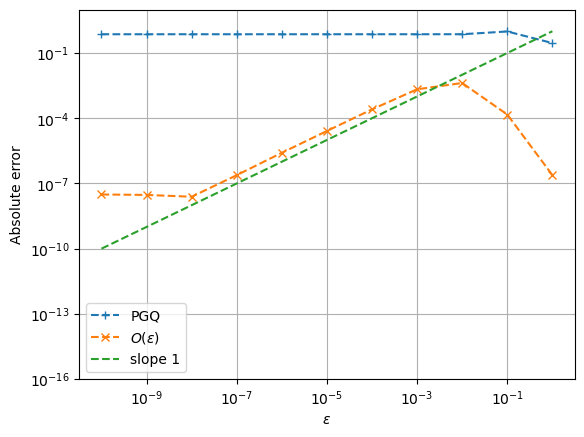

In [8]:
               
plt.figure()
plt.loglog(epsilon, error0, '--+', epsilon, error1, '--x', epsilon, epsilon, '--') 
#plt.loglog(epsilon, error0, 'k', epsilon, error1, '--x') #, epsilon, error2, '--o', epsilon, error3, '--.')
plt.xlabel('$\epsilon$')
plt.ylabel('Absolute error')
#plt.title('Error at point ' + str(j) + ', $\ell$ = ' + str(epsilon[i]))
plt.legend(['PGQ','$O(\epsilon)$', 'slope 1'], loc='best')
plt.grid(True)
plt.ylim([1e-16, 1e1])
#plt.show()

plt.savefig(f'helmholtz_Kw_{KKw}_N_{N}.png')
                        
#for lll in range(1,2):
#    for jj in range(len(epsilon)):
#        plt.figure()
#        plt.loglog(NN, errorN0[lll, :, jj], 'k--', NN, errorN1[lll, :, jj], '--x', NN, errorN2[lll, :, jj], '--o', NN,
#                   errorN3[lll, :, jj], '--.')
#        plt.xlabel('$N$')
#        plt.ylabel('Absolute error')
#        plt.title('Error at point ' + str(lll) + ', $\ell$ = ' + str(epsilon[jj]))
#        plt.legend(['V0', 'V1', 'V2', 'V3'], loc='best')
#        plt.grid(True)
#        plt.ylim([1e-16, 1e0])
#        plt.show()

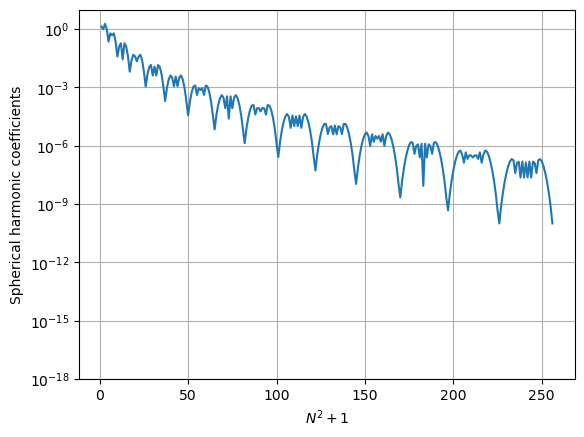

In [9]:
plt.figure()
plt.semilogy( np.arange(1,n_order**2+1), np.abs(mu_nm) )
plt.grid(True)
plt.ylim([1e-18, 1e1])
plt.xlabel(r'$N^2+1$')
plt.ylabel('Spherical harmonic coefficients')
plt.savefig(f'mu_Kw_{KKw}_N_{N}.png')

In [5]:
μ

array([-0.64113212-0.73584268j, -0.85414602-0.63345889j,
       -0.94476234-0.57356551j, -0.57545618-0.75764169j,
        0.10043814-0.72796681j,  0.53981541-0.3577353j ,
        0.67793918-0.02645676j,  0.70101299+0.13373857j,
       -0.66389412-0.72727559j, -0.97632234-0.55026127j,
       -1.2109565 -0.3264566j , -0.93484281-0.58062283j,
       -0.14262247-0.79382904j,  0.45928163-0.46549879j,
        0.66477916-0.0792224j ,  0.70025089+0.12350304j,
       -0.67268902-0.72382099j, -1.02373667-0.51244909j,
       -1.31138379-0.19707112j, -1.07947619-0.46329188j,
       -0.24977092-0.80220649j,  0.42328582-0.50521368j,
        0.65891172-0.09954176j,  0.69993584+0.119566j  ,
       -0.66605581-0.7264366j , -0.98795653-0.54127874j,
       -1.23588548-0.29658237j, -0.97026898-0.55470268j,
       -0.16827892-0.79690643j,  0.45068734-0.47538591j,
        0.66336983-0.08422338j,  0.70018323+0.12254087j,
       -0.64509759-0.73439437j, -0.87530432-0.62042563j,
       -0.99110403-0.53860082j,